In [5]:
!pip install yfinance


/tmp/ipykernel_1082/4240225861.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


=== BACKTEST ANALYSIS FOR RELIANCE.NS ===
Total Completed Trades: 15
Theoretical Strategy Return (No Fees): 13.29%
Real-World Strategy Net Return (With Groww Fees): -41.40%


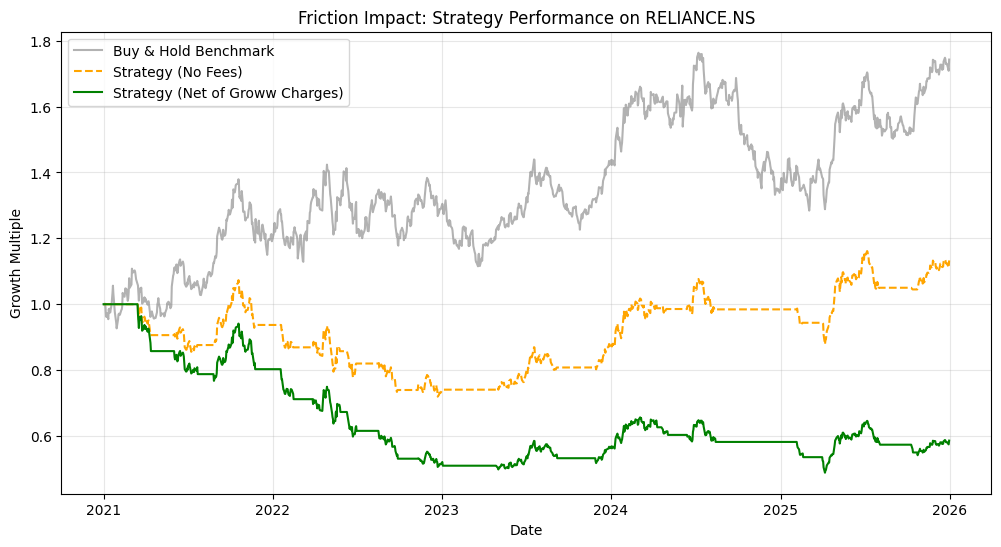

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data
ticker = "RELIANCE.NS"
data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# --- SAFETY FIX FOR MULTIINDEX ---
# If yfinance returned multi-index columns, flatten them out completely
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
# ---------------------------------

df = data[['Close']].copy()

# 2. Calculate Indicators & Trading Signals
df['Fast_SMA'] = df['Close'].rolling(window=20).mean()
df['Slow_SMA'] = df['Close'].rolling(window=50).mean()
df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Detect Transaction Days
df['Trades'] = df['Position'].diff().abs().fillna(0)

# 4. Calculate Raw Market Returns
df['Market_Return'] = df['Close'].pct_change().fillna(0)

# 5. Calculate Exact Groww App Transaction Friction Costs
def calculate_friction(row):
    # Now row['Trades'] is guaranteed to be a single scalar number!
    if float(row['Trades']) == 0.0:
        return 0.0

    # Extracting a scalar float for the closing price
    close_price = float(row['Close'])

    brokerage_pct = 20.0 / close_price
    stt_pct = 0.0010
    exchange_pct = 0.0000297
    sebi_pct = 0.000001

    gst_pct = 0.18 * (brokerage_pct + exchange_pct + sebi_pct)
    stamp_duty_pct = 0.000075

    total_friction_pct = (brokerage_pct + stt_pct + exchange_pct + sebi_pct + gst_pct + stamp_duty_pct)
    return total_friction_pct

# Apply the friction calculation safely
df['Friction_Cost'] = df.apply(calculate_friction, axis=1)

# 6. Compute Strategy Returns Minus Groww/Regulatory Friction
df['Strategy_Return_Raw'] = df['Market_Return'] * df['Position']
df['Strategy_Return_Net'] = df['Strategy_Return_Raw'] - df['Friction_Cost']

# 7. Compounding Growth Comparison
df['Investment_Growth'] = (1 + df['Market_Return']).cumprod()
df['Strategy_Growth_Raw'] = (1 + df['Strategy_Return_Raw']).cumprod()
df['Strategy_Growth_Net'] = (1 + df['Strategy_Return_Net']).cumprod()

# 8. Extract Performance Profiles
total_trades = int(df['Trades'].sum() / 2)
final_net_return = (df['Strategy_Growth_Net'].iloc[-1] - 1) * 100
final_raw_return = (df['Strategy_Growth_Raw'].iloc[-1] - 1) * 100

print(f"=== BACKTEST ANALYSIS FOR {ticker} ===")
print(f"Total Completed Trades: {total_trades}")
print(f"Theoretical Strategy Return (No Fees): {final_raw_return:.2f}%")
print(f"Real-World Strategy Net Return (With Groww Fees): {final_net_return:.2f}%")

# 9. Plotting the Real-World Reality Check
plt.figure(figsize=(12, 6))
plt.plot(df['Investment_Growth'], label='Buy & Hold Benchmark', color='gray', alpha=0.6)
plt.plot(df['Strategy_Growth_Raw'], label='Strategy (No Fees)', color='orange', linestyle='--')
plt.plot(df['Strategy_Growth_Net'], label='Strategy (Net of Groww Charges)', color='green')
plt.title(f"Friction Impact: Strategy Performance on {ticker}")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1082/1546744476.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


=== BACKTEST ANALYSIS FOR DMART.NS ===
Total Completed Trades: 20
Theoretical Strategy Return (No Fees): 23.88%
Real-World Strategy Net Return (With Groww Fees): -6.97%


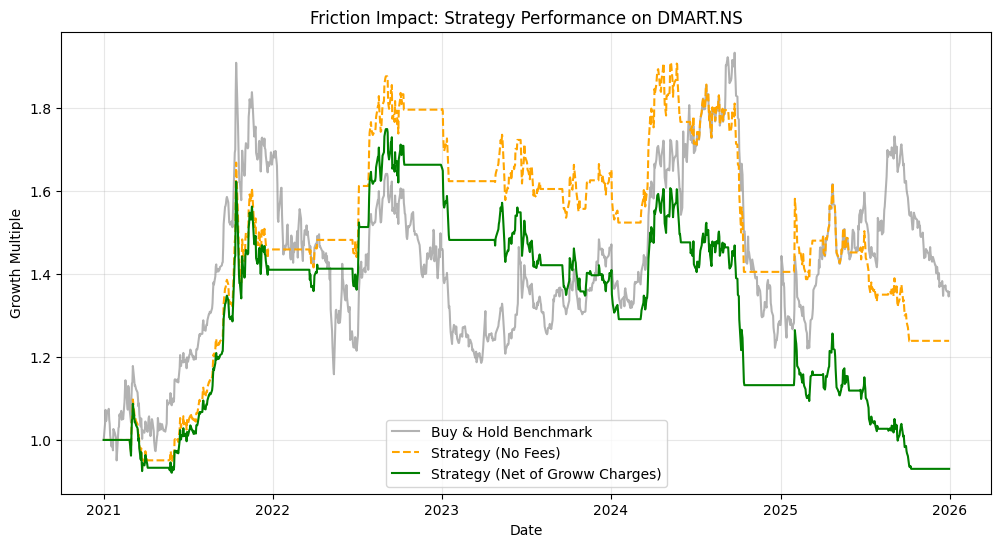

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data
ticker = "DMART.NS"
data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# --- SAFETY FIX FOR MULTIINDEX ---
# If yfinance returned multi-index columns, flatten them out completely
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
# ---------------------------------

df = data[['Close']].copy()

# 2. Calculate Indicators & Trading Signals
df['Fast_SMA'] = df['Close'].rolling(window=25).mean()
df['Slow_SMA'] = df['Close'].rolling(window=40).mean()
df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Detect Transaction Days
df['Trades'] = df['Position'].diff().abs().fillna(0)

# 4. Calculate Raw Market Returns
df['Market_Return'] = df['Close'].pct_change().fillna(0)

# 5. Calculate Exact Groww App Transaction Friction Costs
def calculate_friction(row):
    # Now row['Trades'] is guaranteed to be a single scalar number!
    if float(row['Trades']) == 0.0:
        return 0.0

    # Extracting a scalar float for the closing price
    close_price = float(row['Close'])

    brokerage_pct = 20.0 / close_price
    stt_pct = 0.0010
    exchange_pct = 0.0000297
    sebi_pct = 0.000001

    gst_pct = 0.18 * (brokerage_pct + exchange_pct + sebi_pct)
    stamp_duty_pct = 0.000075

    total_friction_pct = (brokerage_pct + stt_pct + exchange_pct + sebi_pct + gst_pct + stamp_duty_pct)
    return total_friction_pct

# Apply the friction calculation safely
df['Friction_Cost'] = df.apply(calculate_friction, axis=1)

# 6. Compute Strategy Returns Minus Groww/Regulatory Friction
df['Strategy_Return_Raw'] = df['Market_Return'] * df['Position']
df['Strategy_Return_Net'] = df['Strategy_Return_Raw'] - df['Friction_Cost']

# 7. Compounding Growth Comparison
df['Investment_Growth'] = (1 + df['Market_Return']).cumprod()
df['Strategy_Growth_Raw'] = (1 + df['Strategy_Return_Raw']).cumprod()
df['Strategy_Growth_Net'] = (1 + df['Strategy_Return_Net']).cumprod()

# 8. Extract Performance Profiles
total_trades = int(df['Trades'].sum() / 2)
final_net_return = (df['Strategy_Growth_Net'].iloc[-1] - 1) * 100
final_raw_return = (df['Strategy_Growth_Raw'].iloc[-1] - 1) * 100

print(f"=== BACKTEST ANALYSIS FOR {ticker} ===")
print(f"Total Completed Trades: {total_trades}")
print(f"Theoretical Strategy Return (No Fees): {final_raw_return:.2f}%")
print(f"Real-World Strategy Net Return (With Groww Fees): {final_net_return:.2f}%")

# 9. Plotting the Real-World Reality Check
plt.figure(figsize=(12, 6))
plt.plot(df['Investment_Growth'], label='Buy & Hold Benchmark', color='gray', alpha=0.6)
plt.plot(df['Strategy_Growth_Raw'], label='Strategy (No Fees)', color='orange', linestyle='--')
plt.plot(df['Strategy_Growth_Net'], label='Strategy (Net of Groww Charges)', color='green')
plt.title(f"Friction Impact: Strategy Performance on {ticker}")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1082/2754977528.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


=== BACKTEST ANALYSIS FOR DMART.NS ===
Total Completed Trades: 14
Theoretical Strategy Return (No Fees): 20.52%
Real-World Strategy Net Return (With Groww Fees): 16.06%


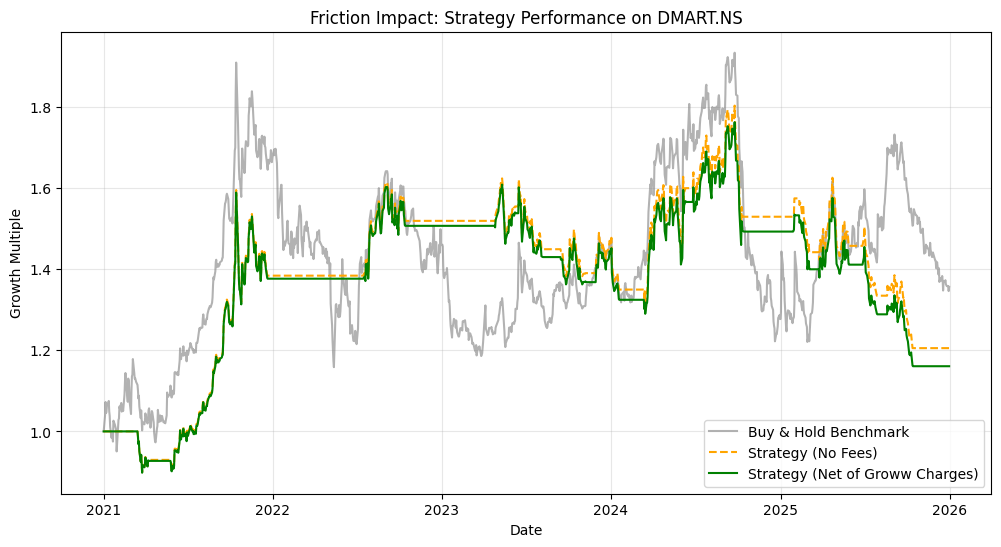

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data
ticker = "DMART.NS"
data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# --- SAFETY FIX FOR MULTIINDEX ---
# If yfinance returned multi-index columns, flatten them out completely
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
# ---------------------------------

df = data[['Close']].copy()

# 2. Calculate Indicators & Trading Signals
df['Fast_SMA'] = df['Close'].rolling(window=20).mean()
df['Slow_SMA'] = df['Close'].rolling(window=50).mean()
df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Detect Transaction Days
df['Trades'] = df['Position'].diff().abs().fillna(0)

# 4. Calculate Raw Market Returns
df['Market_Return'] = df['Close'].pct_change().fillna(0)

# 5. Calculate Exact Groww App Transaction Friction Costs (With ₹1 Lakh Order Size)
def calculate_friction(row):
    if float(row['Trades']) == 0.0:
        return 0.0

    # --- PORTFOLIO SCALE VARIABLE ---
    order_size = 100000.0  # Simulating a fixed ₹1,00,000 trade ticket size
    # --------------------------------

    # Groww charges flat ₹20. On a ₹1L trade, that is scaled to a realistic %
    brokerage_pct = 20.0 / order_size

    stt_pct = 0.0010                     # 0.1% flat
    exchange_pct = 0.0000297             # 0.00297% flat
    sebi_pct = 0.000001                  # 0.0001% flat

    # GST is 18% of Brokerage, Exchange charges, and SEBI fees
    gst_pct = 0.18 * (brokerage_pct + exchange_pct + sebi_pct)
    stamp_duty_pct = 0.000075            # 0.015% on buy side averaged

    total_friction_pct = (brokerage_pct + stt_pct + exchange_pct + sebi_pct + gst_pct + stamp_duty_pct)
    return total_friction_pct

# Apply the friction calculation safely
df['Friction_Cost'] = df.apply(calculate_friction, axis=1)

# 6. Compute Strategy Returns Minus Groww/Regulatory Friction
df['Strategy_Return_Raw'] = df['Market_Return'] * df['Position']
df['Strategy_Return_Net'] = df['Strategy_Return_Raw'] - df['Friction_Cost']

# 7. Compounding Growth Comparison
df['Investment_Growth'] = (1 + df['Market_Return']).cumprod()
df['Strategy_Growth_Raw'] = (1 + df['Strategy_Return_Raw']).cumprod()
df['Strategy_Growth_Net'] = (1 + df['Strategy_Return_Net']).cumprod()

# 8. Extract Performance Profiles
total_trades = int(df['Trades'].sum() / 2)
final_net_return = (df['Strategy_Growth_Net'].iloc[-1] - 1) * 100
final_raw_return = (df['Strategy_Growth_Raw'].iloc[-1] - 1) * 100

print(f"=== BACKTEST ANALYSIS FOR {ticker} ===")
print(f"Total Completed Trades: {total_trades}")
print(f"Theoretical Strategy Return (No Fees): {final_raw_return:.2f}%")
print(f"Real-World Strategy Net Return (With Groww Fees): {final_net_return:.2f}%")

# 9. Plotting the Real-World Reality Check
plt.figure(figsize=(12, 6))
plt.plot(df['Investment_Growth'], label='Buy & Hold Benchmark', color='gray', alpha=0.6)
plt.plot(df['Strategy_Growth_Raw'], label='Strategy (No Fees)', color='orange', linestyle='--')
plt.plot(df['Strategy_Growth_Net'], label='Strategy (Net of Groww Charges)', color='green')
plt.title(f"Friction Impact: Strategy Performance on {ticker}")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1082/1503301250.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


=== BACKTEST ANALYSIS FOR ETERNAL.NS ===
Total Completed Trades: 10
Theoretical Strategy Return (No Fees): 134.14%
Real-World Strategy Net Return (With Groww Fees): 127.93%


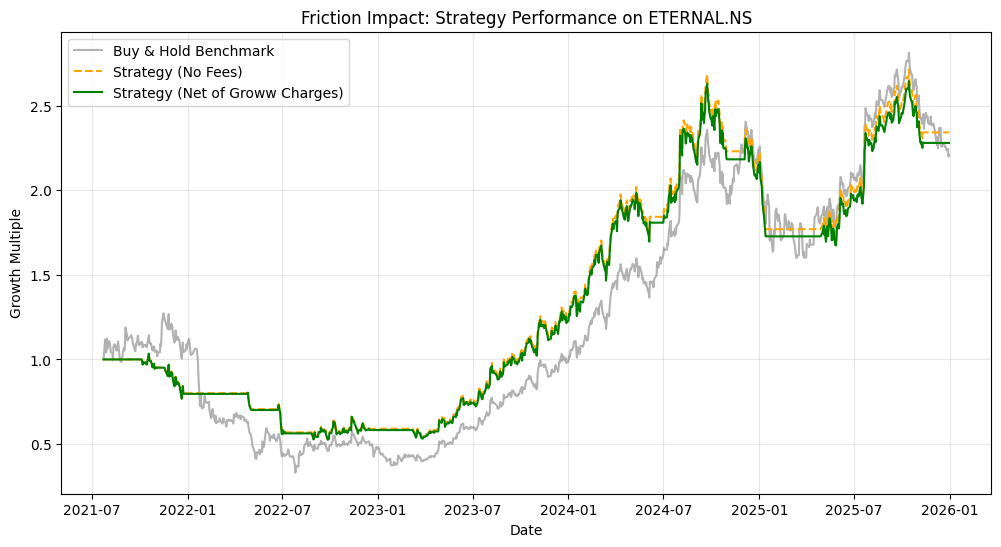

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data
ticker = "ETERNAL.NS"
data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# --- SAFETY FIX FOR MULTIINDEX ---
# If yfinance returned multi-index columns, flatten them out completely
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
# ---------------------------------

df = data[['Close']].copy()

# 2. Calculate Indicators & Trading Signals
df['Fast_SMA'] = df['Close'].rolling(window=20).mean()
df['Slow_SMA'] = df['Close'].rolling(window=50).mean()
df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Detect Transaction Days
df['Trades'] = df['Position'].diff().abs().fillna(0)

# 4. Calculate Raw Market Returns
df['Market_Return'] = df['Close'].pct_change().fillna(0)

# 5. Calculate Exact Groww App Transaction Friction Costs (With ₹1 Lakh Order Size)
def calculate_friction(row):
    if float(row['Trades']) == 0.0:
        return 0.0

    # --- PORTFOLIO SCALE VARIABLE ---
    order_size = 100000.0  # Simulating a fixed ₹1,00,000 trade ticket size
    # --------------------------------

    # Groww charges flat ₹20. On a ₹1L trade, that is scaled to a realistic %
    brokerage_pct = 20.0 / order_size

    stt_pct = 0.0010                     # 0.1% flat
    exchange_pct = 0.0000297             # 0.00297% flat
    sebi_pct = 0.000001                  # 0.0001% flat

    # GST is 18% of Brokerage, Exchange charges, and SEBI fees
    gst_pct = 0.18 * (brokerage_pct + exchange_pct + sebi_pct)
    stamp_duty_pct = 0.000075            # 0.015% on buy side averaged

    total_friction_pct = (brokerage_pct + stt_pct + exchange_pct + sebi_pct + gst_pct + stamp_duty_pct)
    return total_friction_pct

# Apply the friction calculation safely
df['Friction_Cost'] = df.apply(calculate_friction, axis=1)

# 6. Compute Strategy Returns Minus Groww/Regulatory Friction
df['Strategy_Return_Raw'] = df['Market_Return'] * df['Position']
df['Strategy_Return_Net'] = df['Strategy_Return_Raw'] - df['Friction_Cost']

# 7. Compounding Growth Comparison
df['Investment_Growth'] = (1 + df['Market_Return']).cumprod()
df['Strategy_Growth_Raw'] = (1 + df['Strategy_Return_Raw']).cumprod()
df['Strategy_Growth_Net'] = (1 + df['Strategy_Return_Net']).cumprod()

# 8. Extract Performance Profiles
total_trades = int(df['Trades'].sum() / 2)
final_net_return = (df['Strategy_Growth_Net'].iloc[-1] - 1) * 100
final_raw_return = (df['Strategy_Growth_Raw'].iloc[-1] - 1) * 100

print(f"=== BACKTEST ANALYSIS FOR {ticker} ===")
print(f"Total Completed Trades: {total_trades}")
print(f"Theoretical Strategy Return (No Fees): {final_raw_return:.2f}%")
print(f"Real-World Strategy Net Return (With Groww Fees): {final_net_return:.2f}%")

# 9. Plotting the Real-World Reality Check
plt.figure(figsize=(12, 6))
plt.plot(df['Investment_Growth'], label='Buy & Hold Benchmark', color='gray', alpha=0.6)
plt.plot(df['Strategy_Growth_Raw'], label='Strategy (No Fees)', color='orange', linestyle='--')
plt.plot(df['Strategy_Growth_Net'], label='Strategy (Net of Groww Charges)', color='green')
plt.title(f"Friction Impact: Strategy Performance on {ticker}")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1082/1930455973.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


=== BACKTEST ANALYSIS FOR IDEA.NS ===
Total Completed Trades: 12
Theoretical Strategy Return (No Fees): 10.42%
Real-World Strategy Net Return (With Groww Fees): 6.76%


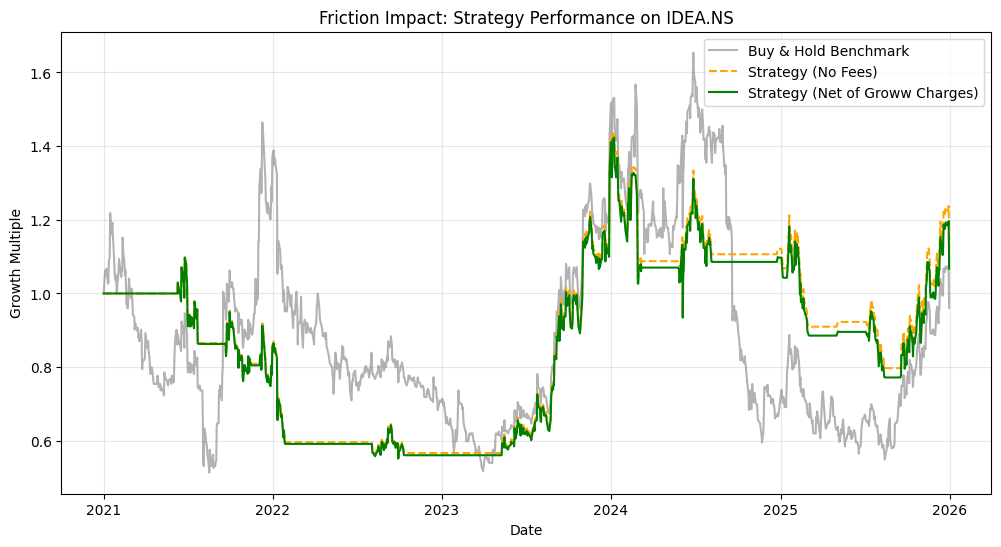

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data
ticker = "IDEA.NS"
data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# --- SAFETY FIX FOR MULTIINDEX ---
# If yfinance returned multi-index columns, flatten them out completely
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
# ---------------------------------

df = data[['Close']].copy()

# 2. Calculate Indicators & Trading Signals
df['Fast_SMA'] = df['Close'].rolling(window=20).mean()
df['Slow_SMA'] = df['Close'].rolling(window=50).mean()
df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Detect Transaction Days
df['Trades'] = df['Position'].diff().abs().fillna(0)

# 4. Calculate Raw Market Returns
df['Market_Return'] = df['Close'].pct_change().fillna(0)

# 5. Calculate Exact Groww App Transaction Friction Costs (With ₹1 Lakh Order Size)
def calculate_friction(row):
    if float(row['Trades']) == 0.0:
        return 0.0

    # --- PORTFOLIO SCALE VARIABLE ---
    order_size = 100000.0  # Simulating a fixed ₹1,00,000 trade ticket size
    # --------------------------------

    # Groww charges flat ₹20. On a ₹1L trade, that is scaled to a realistic %
    brokerage_pct = 20.0 / order_size

    stt_pct = 0.0010                     # 0.1% flat
    exchange_pct = 0.0000297             # 0.00297% flat
    sebi_pct = 0.000001                  # 0.0001% flat

    # GST is 18% of Brokerage, Exchange charges, and SEBI fees
    gst_pct = 0.18 * (brokerage_pct + exchange_pct + sebi_pct)
    stamp_duty_pct = 0.000075            # 0.015% on buy side averaged

    total_friction_pct = (brokerage_pct + stt_pct + exchange_pct + sebi_pct + gst_pct + stamp_duty_pct)
    return total_friction_pct

# Apply the friction calculation safely
df['Friction_Cost'] = df.apply(calculate_friction, axis=1)

# 6. Compute Strategy Returns Minus Groww/Regulatory Friction
df['Strategy_Return_Raw'] = df['Market_Return'] * df['Position']
df['Strategy_Return_Net'] = df['Strategy_Return_Raw'] - df['Friction_Cost']

# 7. Compounding Growth Comparison
df['Investment_Growth'] = (1 + df['Market_Return']).cumprod()
df['Strategy_Growth_Raw'] = (1 + df['Strategy_Return_Raw']).cumprod()
df['Strategy_Growth_Net'] = (1 + df['Strategy_Return_Net']).cumprod()

# 8. Extract Performance Profiles
total_trades = int(df['Trades'].sum() / 2)
final_net_return = (df['Strategy_Growth_Net'].iloc[-1] - 1) * 100
final_raw_return = (df['Strategy_Growth_Raw'].iloc[-1] - 1) * 100

print(f"=== BACKTEST ANALYSIS FOR {ticker} ===")
print(f"Total Completed Trades: {total_trades}")
print(f"Theoretical Strategy Return (No Fees): {final_raw_return:.2f}%")
print(f"Real-World Strategy Net Return (With Groww Fees): {final_net_return:.2f}%")

# 9. Plotting the Real-World Reality Check
plt.figure(figsize=(12, 6))
plt.plot(df['Investment_Growth'], label='Buy & Hold Benchmark', color='gray', alpha=0.6)
plt.plot(df['Strategy_Growth_Raw'], label='Strategy (No Fees)', color='orange', linestyle='--')
plt.plot(df['Strategy_Growth_Net'], label='Strategy (Net of Groww Charges)', color='green')
plt.title(f"Friction Impact: Strategy Performance on {ticker}")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1082/3778415265.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


=== BACKTEST ANALYSIS FOR ADANIENT.NS ===
Total Completed Trades: 12
Theoretical Strategy Return (No Fees): 265.89%
Real-World Strategy Net Return (With Groww Fees): 254.29%


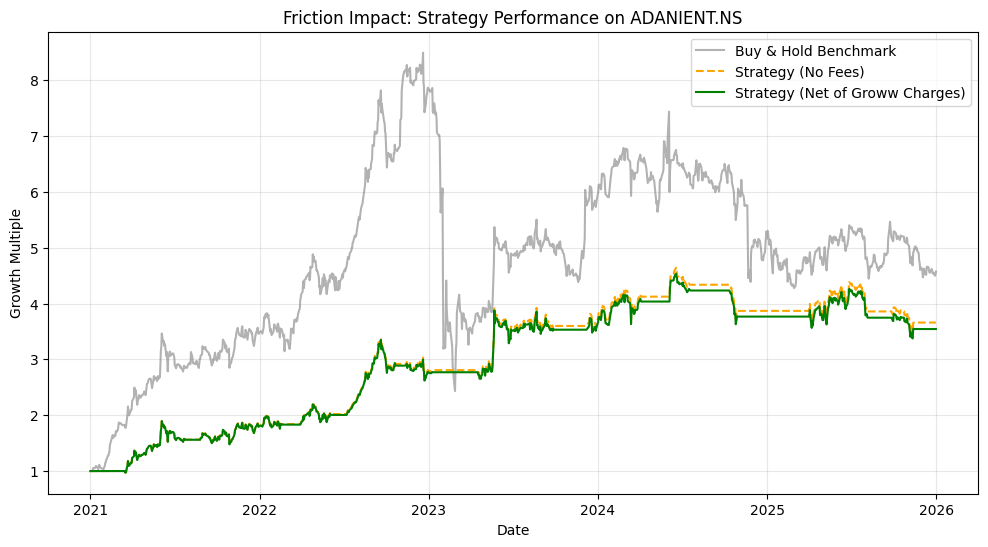

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data
ticker = "ADANIENT.NS"
data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# --- SAFETY FIX FOR MULTIINDEX ---
# If yfinance returned multi-index columns, flatten them out completely
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
# ---------------------------------

df = data[['Close']].copy()

# 2. Calculate Indicators & Trading Signals
df['Fast_SMA'] = df['Close'].rolling(window=20).mean()
df['Slow_SMA'] = df['Close'].rolling(window=50).mean()
df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Detect Transaction Days
df['Trades'] = df['Position'].diff().abs().fillna(0)

# 4. Calculate Raw Market Returns
df['Market_Return'] = df['Close'].pct_change().fillna(0)

# 5. Calculate Exact Groww App Transaction Friction Costs (With ₹1 Lakh Order Size)
def calculate_friction(row):
    if float(row['Trades']) == 0.0:
        return 0.0

    # --- PORTFOLIO SCALE VARIABLE ---
    order_size = 100000.0  # Simulating a fixed ₹1,00,000 trade ticket size
    # --------------------------------

    # Groww charges flat ₹20. On a ₹1L trade, that is scaled to a realistic %
    brokerage_pct = 20.0 / order_size

    stt_pct = 0.0010                     # 0.1% flat
    exchange_pct = 0.0000297             # 0.00297% flat
    sebi_pct = 0.000001                  # 0.0001% flat

    # GST is 18% of Brokerage, Exchange charges, and SEBI fees
    gst_pct = 0.18 * (brokerage_pct + exchange_pct + sebi_pct)
    stamp_duty_pct = 0.000075            # 0.015% on buy side averaged

    total_friction_pct = (brokerage_pct + stt_pct + exchange_pct + sebi_pct + gst_pct + stamp_duty_pct)
    return total_friction_pct

# Apply the friction calculation safely
df['Friction_Cost'] = df.apply(calculate_friction, axis=1)

# 6. Compute Strategy Returns Minus Groww/Regulatory Friction
df['Strategy_Return_Raw'] = df['Market_Return'] * df['Position']
df['Strategy_Return_Net'] = df['Strategy_Return_Raw'] - df['Friction_Cost']

# 7. Compounding Growth Comparison
df['Investment_Growth'] = (1 + df['Market_Return']).cumprod()
df['Strategy_Growth_Raw'] = (1 + df['Strategy_Return_Raw']).cumprod()
df['Strategy_Growth_Net'] = (1 + df['Strategy_Return_Net']).cumprod()

# 8. Extract Performance Profiles
total_trades = int(df['Trades'].sum() / 2)
final_net_return = (df['Strategy_Growth_Net'].iloc[-1] - 1) * 100
final_raw_return = (df['Strategy_Growth_Raw'].iloc[-1] - 1) * 100

print(f"=== BACKTEST ANALYSIS FOR {ticker} ===")
print(f"Total Completed Trades: {total_trades}")
print(f"Theoretical Strategy Return (No Fees): {final_raw_return:.2f}%")
print(f"Real-World Strategy Net Return (With Groww Fees): {final_net_return:.2f}%")

# 9. Plotting the Real-World Reality Check
plt.figure(figsize=(12, 6))
plt.plot(df['Investment_Growth'], label='Buy & Hold Benchmark', color='gray', alpha=0.6)
plt.plot(df['Strategy_Growth_Raw'], label='Strategy (No Fees)', color='orange', linestyle='--')
plt.plot(df['Strategy_Growth_Net'], label='Strategy (Net of Groww Charges)', color='green')
plt.title(f"Friction Impact: Strategy Performance on {ticker}")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1082/1011359563.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


=== BACKTEST ANALYSIS FOR GILLETTE.NS ===
Total Completed Trades: 12
Theoretical Strategy Return (No Fees): 94.33%
Real-World Strategy Net Return (With Groww Fees): 88.15%


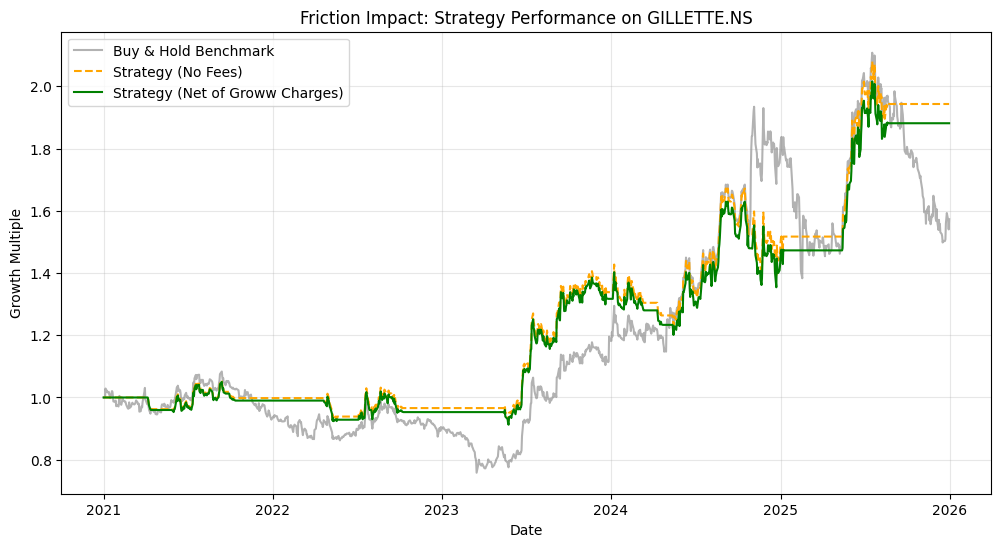

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data
ticker = "GILLETTE.NS"
data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# --- SAFETY FIX FOR MULTIINDEX ---
# If yfinance returned multi-index columns, flatten them out completely
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
# ---------------------------------

df = data[['Close']].copy()

# 2. Calculate Indicators & Trading Signals
df['Fast_SMA'] = df['Close'].rolling(window=20).mean()
df['Slow_SMA'] = df['Close'].rolling(window=50).mean()
df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Detect Transaction Days
df['Trades'] = df['Position'].diff().abs().fillna(0)

# 4. Calculate Raw Market Returns
df['Market_Return'] = df['Close'].pct_change().fillna(0)

# 5. Calculate Exact Groww App Transaction Friction Costs (With ₹1 Lakh Order Size)
def calculate_friction(row):
    if float(row['Trades']) == 0.0:
        return 0.0

    # --- PORTFOLIO SCALE VARIABLE ---
    order_size = 100000.0  # Simulating a fixed ₹1,00,000 trade ticket size
    # --------------------------------

    # Groww charges flat ₹20. On a ₹1L trade, that is scaled to a realistic %
    brokerage_pct = 20.0 / order_size

    stt_pct = 0.0010                     # 0.1% flat
    exchange_pct = 0.0000297             # 0.00297% flat
    sebi_pct = 0.000001                  # 0.0001% flat

    # GST is 18% of Brokerage, Exchange charges, and SEBI fees
    gst_pct = 0.18 * (brokerage_pct + exchange_pct + sebi_pct)
    stamp_duty_pct = 0.000075            # 0.015% on buy side averaged

    total_friction_pct = (brokerage_pct + stt_pct + exchange_pct + sebi_pct + gst_pct + stamp_duty_pct)
    return total_friction_pct

# Apply the friction calculation safely
df['Friction_Cost'] = df.apply(calculate_friction, axis=1)

# 6. Compute Strategy Returns Minus Groww/Regulatory Friction
df['Strategy_Return_Raw'] = df['Market_Return'] * df['Position']
df['Strategy_Return_Net'] = df['Strategy_Return_Raw'] - df['Friction_Cost']

# 7. Compounding Growth Comparison
df['Investment_Growth'] = (1 + df['Market_Return']).cumprod()
df['Strategy_Growth_Raw'] = (1 + df['Strategy_Return_Raw']).cumprod()
df['Strategy_Growth_Net'] = (1 + df['Strategy_Return_Net']).cumprod()

# 8. Extract Performance Profiles
total_trades = int(df['Trades'].sum() / 2)
final_net_return = (df['Strategy_Growth_Net'].iloc[-1] - 1) * 100
final_raw_return = (df['Strategy_Growth_Raw'].iloc[-1] - 1) * 100

print(f"=== BACKTEST ANALYSIS FOR {ticker} ===")
print(f"Total Completed Trades: {total_trades}")
print(f"Theoretical Strategy Return (No Fees): {final_raw_return:.2f}%")
print(f"Real-World Strategy Net Return (With Groww Fees): {final_net_return:.2f}%")

# 9. Plotting the Real-World Reality Check
plt.figure(figsize=(12, 6))
plt.plot(df['Investment_Growth'], label='Buy & Hold Benchmark', color='gray', alpha=0.6)
plt.plot(df['Strategy_Growth_Raw'], label='Strategy (No Fees)', color='orange', linestyle='--')
plt.plot(df['Strategy_Growth_Net'], label='Strategy (Net of Groww Charges)', color='green')
plt.title(f"Friction Impact: Strategy Performance on {ticker}")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1082/1878954822.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


=== BACKTEST ANALYSIS FOR MRF.NS ===
Total Completed Trades: 16
Theoretical Strategy Return (No Fees): 39.65%
Real-World Strategy Net Return (With Groww Fees): 33.77%


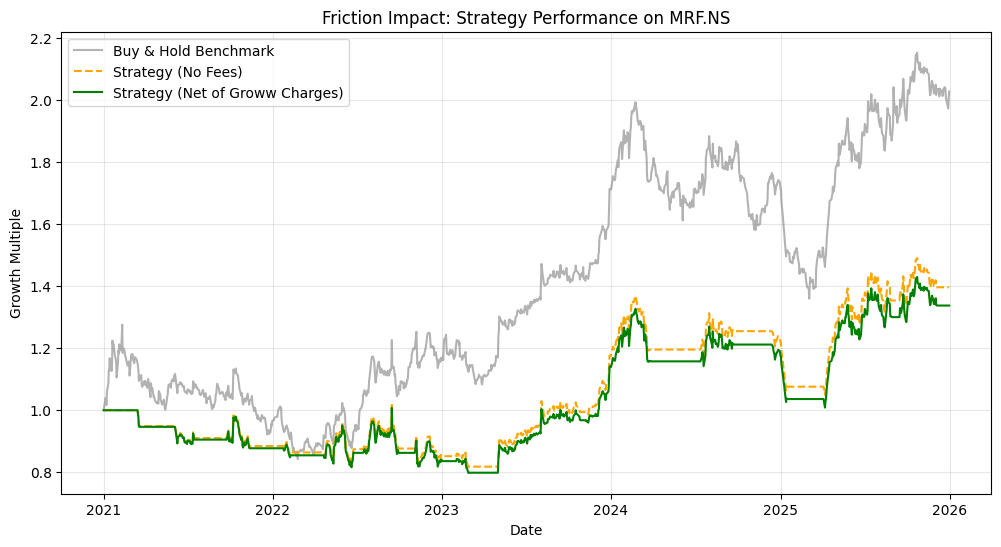

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Download Data
ticker = "MRF.NS"
data = yf.download(ticker, start="2021-01-01", end="2026-01-01")

# --- SAFETY FIX FOR MULTIINDEX ---
# If yfinance returned multi-index columns, flatten them out completely
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
# ---------------------------------

df = data[['Close']].copy()

# 2. Calculate Indicators & Trading Signals
df['Fast_SMA'] = df['Close'].rolling(window=20).mean()
df['Slow_SMA'] = df['Close'].rolling(window=50).mean()
df['Signal'] = np.where(df['Fast_SMA'] > df['Slow_SMA'], 1, 0)
df['Position'] = df['Signal'].shift(1).fillna(0)

# 3. Detect Transaction Days
df['Trades'] = df['Position'].diff().abs().fillna(0)

# 4. Calculate Raw Market Returns
df['Market_Return'] = df['Close'].pct_change().fillna(0)

# 5. Calculate Exact Groww App Transaction Friction Costs (With ₹1 Lakh Order Size)
def calculate_friction(row):
    if float(row['Trades']) == 0.0:
        return 0.0

    # --- PORTFOLIO SCALE VARIABLE ---
    order_size = 100000.0  # Simulating a fixed ₹1,00,000 trade ticket size
    # --------------------------------

    # Groww charges flat ₹20. On a ₹1L trade, that is scaled to a realistic %
    brokerage_pct = 20.0 / order_size

    stt_pct = 0.0010                     # 0.1% flat
    exchange_pct = 0.0000297             # 0.00297% flat
    sebi_pct = 0.000001                  # 0.0001% flat

    # GST is 18% of Brokerage, Exchange charges, and SEBI fees
    gst_pct = 0.18 * (brokerage_pct + exchange_pct + sebi_pct)
    stamp_duty_pct = 0.000075            # 0.015% on buy side averaged

    total_friction_pct = (brokerage_pct + stt_pct + exchange_pct + sebi_pct + gst_pct + stamp_duty_pct)
    return total_friction_pct

# Apply the friction calculation safely
df['Friction_Cost'] = df.apply(calculate_friction, axis=1)

# 6. Compute Strategy Returns Minus Groww/Regulatory Friction
df['Strategy_Return_Raw'] = df['Market_Return'] * df['Position']
df['Strategy_Return_Net'] = df['Strategy_Return_Raw'] - df['Friction_Cost']

# 7. Compounding Growth Comparison
df['Investment_Growth'] = (1 + df['Market_Return']).cumprod()
df['Strategy_Growth_Raw'] = (1 + df['Strategy_Return_Raw']).cumprod()
df['Strategy_Growth_Net'] = (1 + df['Strategy_Return_Net']).cumprod()

# 8. Extract Performance Profiles
total_trades = int(df['Trades'].sum() / 2)
final_net_return = (df['Strategy_Growth_Net'].iloc[-1] - 1) * 100
final_raw_return = (df['Strategy_Growth_Raw'].iloc[-1] - 1) * 100

print(f"=== BACKTEST ANALYSIS FOR {ticker} ===")
print(f"Total Completed Trades: {total_trades}")
print(f"Theoretical Strategy Return (No Fees): {final_raw_return:.2f}%")
print(f"Real-World Strategy Net Return (With Groww Fees): {final_net_return:.2f}%")

# 9. Plotting the Real-World Reality Check
plt.figure(figsize=(12, 6))
plt.plot(df['Investment_Growth'], label='Buy & Hold Benchmark', color='gray', alpha=0.6)
plt.plot(df['Strategy_Growth_Raw'], label='Strategy (No Fees)', color='orange', linestyle='--')
plt.plot(df['Strategy_Growth_Net'], label='Strategy (Net of Groww Charges)', color='green')
plt.title(f"Friction Impact: Strategy Performance on {ticker}")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()